# Exploratory Data Analysis
Investigating the relationship between **GDP per capita**, **health expenditure (% of GDP)**, **conflict status**, and **life expectancy** across countries over time.

Data sourced from the [World Bank Open Data](https://data.worldbank.org/) platform.

In [38]:
import pandas as pd

In [ ]:
# there are 4 metadata rows before the actaul header
raw_gdp_df = pd.read_csv("data/raw/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv", skiprows=4)

In [40]:
raw_gdp_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,28440.041688,30082.158423,30645.890602,22759.807175,26749.329609,30975.998912,35718.753119,39498.594129,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.089204,186.909053,197.367547,225.400079,208.962717,226.836135,...,1528.104224,1552.073722,1507.085600,1351.591669,1562.416175,1679.327622,1571.449189,1615.396356,NaN,NaN
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (current US$),NY.GDP.PCAP.CD,121.936832,127.451040,133.823783,139.004980,148.545883,155.561897,...,1574.230564,1720.140092,2216.385055,2030.861659,2112.794076,2138.473153,1841.855064,1411.337029,NaN,NaN
4,Angola,AGO,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2790.718869,2860.093648,2493.678844,1759.356199,2303.908127,3682.113151,2916.136633,2665.874448,NaN,NaN


In [41]:
# checking if all rows have country code so i can use it as an id
int(raw_gdp_df["Country Code"].isna().sum())

0

### Reshaping Wide to Long
The raw data has years as columns. Pivoting to a long format with `(year, country_code)` as the grain makes it much easier to merge and plot.

In [42]:
# i noticed all the datasets have the same structure so generalizing it as a func
def pivot_dataset(raw_df, kpi_name):
    id_cols = ["Country Code", "Country Name"]

    # imma ttranspose this
    year_cols = [col for col in raw_df.columns if col.isdigit()]

    # pivot to get year, country_code, country_name, kpi_name
    pivot_df = raw_df.melt(
        id_vars=id_cols,
        value_vars=year_cols,
        var_name="year",
        value_name=kpi_name
    ).rename(columns={"Country Code": "country_code", "Country Name": "country_name"})

    pivot_df = pivot_df[["year", "country_code", "country_name", kpi_name]].copy()
    pivot_df["year"] = pivot_df["year"].astype(int)
    return pivot_df

In [46]:
gdp_df = pivot_dataset(raw_gdp_df, "gdp_per_capita_usd")
gdp_df.head(10)

,year,country_code,country_name,gdp_per_capita_usd
0,1960,ABW,Aruba,NaN
1,1960,AFE,Africa Eastern and Southern,186.089204
2,1960,AFG,Afghanistan,NaN
3,1960,AFW,Africa Western and Central,121.936832
4,1960,AGO,Angola,NaN
5,1960,ALB,Albania,NaN
6,1960,AND,Andorra,NaN
7,1960,ARB,Arab World,NaN
8,1960,ARE,United Arab Emirates,NaN
9,1960,ARG,Argentina,778.251707


In [ ]:
# metadata files all contain the same data: region and income group
metadata_df = pd.read_csv("data/raw/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46/Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv")
metadata_df = metadata_df[["Country Code", "Region", "IncomeGroup"]].rename(
    columns={"Country Code": "country_code", "Region": "region", "IncomeGroup": "income_group"}
)
gdp_df = gdp_df.merge(
    metadata_df,
    on="country_code",
    how="outer"
)

gdp_df.head(10)

,year,country_code,country_name,gdp_per_capita_usd,region,income_group
0,1960,ABW,Aruba,NaN,Latin America & Caribbean,High income
1,1960,AFE,Africa Eastern and Southern,186.089204,NaN,NaN
2,1960,AFG,Afghanistan,NaN,Middle East & North Africa,Low income
3,1960,AFW,Africa Western and Central,121.936832,NaN,NaN
4,1960,AGO,Angola,NaN,Sub-Saharan Africa,Lower middle income
5,1960,ALB,Albania,NaN,Europe & Central Asia,Upper middle income
6,1960,AND,Andorra,NaN,Europe & Central Asia,High income
7,1960,ARB,Arab World,NaN,NaN,NaN
8,1960,ARE,United Arab Emirates,NaN,Middle East & North Africa,High income
9,1960,ARG,Argentina,778.251707,Latin America & Caribbean,Upper middle income


In [48]:
# i noticed that from the metadata, if the row has a region its not like a Arab Region or World aggregated region
gdp_df["is_aggregated_region"] = gdp_df["region"].isna() | (gdp_df["region"] == "")
gdp_df.head(10)

,year,country_code,country_name,gdp_per_capita_usd,region,income_group,is_aggregated_region
0,1960,ABW,Aruba,NaN,Latin America & Caribbean,High income,False
1,1960,AFE,Africa Eastern and Southern,186.089204,NaN,NaN,True
2,1960,AFG,Afghanistan,NaN,Middle East & North Africa,Low income,False
3,1960,AFW,Africa Western and Central,121.936832,NaN,NaN,True
4,1960,AGO,Angola,NaN,Sub-Saharan Africa,Lower middle income,False
5,1960,ALB,Albania,NaN,Europe & Central Asia,Upper middle income,False
6,1960,AND,Andorra,NaN,Europe & Central Asia,High income,False
7,1960,ARB,Arab World,NaN,NaN,NaN,True
8,1960,ARE,United Arab Emirates,NaN,Middle East & North Africa,High income,False
9,1960,ARG,Argentina,778.251707,Latin America & Caribbean,Upper middle income,False


### Loading Life Expectancy & Health Expenditure
Same World Bank format, same pivoting logic. Health expenditure is measured as a percentage of GDP.

In [ ]:
raw_life_expectancy_df = pd.read_csv("data/raw/API_SP.DYN.LE00.IN_DS2_en_csv_v2_128/API_SP.DYN.LE00.IN_DS2_en_csv_v2_128.csv", skiprows=4)
raw_life_expectancy_df.head(10)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,64.049000,64.215000,64.602000,64.944000,65.303000,65.615000,...,75.620000,75.880000,76.019000,75.406000,73.655000,76.226000,76.353000,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,44.169658,44.468838,44.877890,45.160583,45.535695,45.770723,...,62.591275,63.330691,63.857261,63.766484,62.979999,64.487020,65.146154,NaN,NaN,NaN
2,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,32.799000,33.291000,33.757000,34.201000,34.673000,35.124000,...,62.406000,62.443000,62.941000,61.454000,60.417000,65.617000,66.035000,NaN,NaN,NaN
3,Africa Western and Central,AFW,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,37.779636,38.058956,38.681792,38.936918,39.194580,39.479784,...,56.626439,57.036976,57.149847,57.364425,57.362572,57.987813,58.855722,NaN,NaN,NaN
4,Angola,AGO,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,37.933000,36.902000,37.168000,37.419000,37.704000,37.968000,...,62.122000,62.622000,63.051000,63.116000,62.958000,64.246000,64.617000,NaN,NaN,NaN
5,Albania,ALB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,56.413000,57.488000,58.494000,59.479000,60.404000,61.273000,...,78.900000,79.238000,79.467000,77.824000,76.844000,78.769000,79.602000,NaN,NaN,NaN
6,Andorra,AND,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,72.094000,72.573000,72.993000,73.298000,73.624000,73.856000,...,84.359000,84.242000,84.098000,79.418000,82.331000,84.016000,84.041000,NaN,NaN,NaN
7,Arab World,ARB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,44.794056,45.545371,45.993769,46.979338,47.570034,48.117159,...,71.112856,71.431300,71.839893,70.726559,70.404114,71.876096,72.444678,NaN,NaN,NaN
8,United Arab Emirates,ARE,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,50.651000,51.596000,52.546000,53.509000,54.495000,55.512000,...,82.388000,82.449000,82.596000,81.936000,79.083000,80.487000,82.909000,NaN,NaN,NaN
9,Argentina,ARG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,64.242000,64.631000,64.618000,64.855000,64.816000,65.053000,...,76.543000,76.770000,76.847000,75.878000,73.948000,75.806000,77.395000,NaN,NaN,NaN


In [50]:
life_expectancy_df = pivot_dataset(raw_life_expectancy_df, "life_expectancy_years")
life_expectancy_df.head(10)

,year,country_code,country_name,life_expectancy_years
0,1960,ABW,Aruba,64.049000
1,1960,AFE,Africa Eastern and Southern,44.169658
2,1960,AFG,Afghanistan,32.799000
3,1960,AFW,Africa Western and Central,37.779636
4,1960,AGO,Angola,37.933000
5,1960,ALB,Albania,56.413000
6,1960,AND,Andorra,72.094000
7,1960,ARB,Arab World,44.794056
8,1960,ARE,United Arab Emirates,50.651000
9,1960,ARG,Argentina,64.242000


In [ ]:
raw_health_expenditure_df = pd.read_csv("data/raw/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_558/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_558.csv", skiprows=4)
raw_health_expenditure_df.head(10)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,5.865882,5.730629,5.755890,5.984597,5.942595,5.559021,5.540810,NaN,NaN,NaN
2,Afghanistan,AFG,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,12.620817,14.208419,14.831320,15.533614,21.508444,23.088169,14.985763,NaN,NaN,NaN
3,Africa Western and Central,AFW,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,3.732668,3.288622,3.250936,3.788444,4.135622,4.174496,4.143225,NaN,NaN,NaN
4,Angola,AGO,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.437943,2.298875,2.203943,2.816889,2.739871,2.600410,2.546929,NaN,NaN,NaN
5,Albania,ALB,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.501119,6.590024,6.781441,7.465137,7.357504,7.536462,7.052403,NaN,NaN,NaN
6,Andorra,AND,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,7.071582,7.377811,7.322386,8.784620,8.646717,7.521358,7.699280,NaN,NaN,NaN
7,Arab World,ARB,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,5.159873,4.867767,4.942787,5.718445,5.259286,4.665253,5.157803,NaN,NaN,NaN
8,United Arab Emirates,ARE,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,4.008550,4.098542,4.402913,5.824770,5.304943,4.565364,4.970951,NaN,NaN,NaN
9,Argentina,ARG,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,10.260579,10.172893,10.119113,10.672463,11.009102,10.159505,10.269518,NaN,NaN,NaN


In [52]:
health_expenditure_df = pivot_dataset(raw_health_expenditure_df, "perc_health_expenditure_of_gdp")
health_expenditure_df.head(10)

,year,country_code,country_name,perc_health_expenditure_of_gdp
0,1960,ABW,Aruba,NaN
1,1960,AFE,Africa Eastern and Southern,NaN
2,1960,AFG,Afghanistan,NaN
3,1960,AFW,Africa Western and Central,NaN
4,1960,AGO,Angola,NaN
5,1960,ALB,Albania,NaN
6,1960,AND,Andorra,NaN
7,1960,ARB,Arab World,NaN
8,1960,ARE,United Arab Emirates,NaN
9,1960,ARG,Argentina,NaN


### Merging All Indicators
Joining GDP, life expectancy, and health expenditure into a single panel on `(year, country_code)`, and then bringing in the conflict flags.

In [58]:
# merging all 3 datasets
merged_df = (
    gdp_df.merge(
        life_expectancy_df.drop(columns=["country_name"]),
        on=["year", "country_code"],
        how="outer",
    )
    .merge(
        health_expenditure_df.drop(columns=["country_name"]),
        on=["year", "country_code"],
        how="outer",
    )
)

merged_df = merged_df[
    [
        'year',
        'country_code', 'country_name', 'region',
        'gdp_per_capita_usd', 'life_expectancy_years', 'perc_health_expenditure_of_gdp',
        'income_group', 'is_aggregated_region'
    ]
]
merged_df.head(10)

,year,country_code,country_name,region,gdp_per_capita_usd,life_expectancy_years,perc_health_expenditure_of_gdp,income_group,is_aggregated_region
0,1960,ABW,Aruba,Latin America & Caribbean,NaN,64.049000,NaN,High income,False
1,1960,AFE,Africa Eastern and Southern,NaN,186.089204,44.169658,NaN,NaN,True
2,1960,AFG,Afghanistan,Middle East & North Africa,NaN,32.799000,NaN,Low income,False
3,1960,AFW,Africa Western and Central,NaN,121.936832,37.779636,NaN,NaN,True
4,1960,AGO,Angola,Sub-Saharan Africa,NaN,37.933000,NaN,Lower middle income,False
5,1960,ALB,Albania,Europe & Central Asia,NaN,56.413000,NaN,Upper middle income,False
6,1960,AND,Andorra,Europe & Central Asia,NaN,72.094000,NaN,High income,False
7,1960,ARB,Arab World,NaN,NaN,44.794056,NaN,NaN,True
8,1960,ARE,United Arab Emirates,Middle East & North Africa,NaN,50.651000,NaN,High income,False
9,1960,ARG,Argentina,Latin America & Caribbean,778.251707,64.242000,NaN,Upper middle income,False


### Conflict & Fragility Data
The World Bank publishes a Fragile and Conflict-affected Situations (FCS) list. Manually compiled a CSV from that to flag conflict-affected country-years in the dataset.

In [59]:
# prof wanted conflict/war data, world bank has a list (FCS) so i manually made a csv dtaset from that

In [ ]:
raw_conflict_df = pd.read_csv("data/raw/ConflictCountries/conflict_countries.csv")
conflict_countries = raw_conflict_df["country_name"].drop_duplicates().sort_values().reset_index(drop=True)

map_country_code = merged_df[["country_code", "country_name"]].drop_duplicates().reset_index(drop=True)

In [63]:
mapped = conflict_countries.to_frame("country_name").merge(
    map_country_code, on="country_name", how="left"
)
n_mapped = mapped["country_code"].notna().sum()
n_unmapped = mapped["country_code"].isna().sum()

In [ ]:
print(f"num conflict countries = {len(conflict_countries)}")
print(f"num mapped to code = {n_mapped}")
print("\nUnmapped countries:", mapped.loc[mapped["country_code"].isna(), "country_name"].tolist())

num conflict countries = 63
num mapped to code = 52

Unmapped countries: ["Côte d'Ivoire", 'Democratic Republic of Congo', 'Gambia', 'Laos', 'Micronesia', 'Republic of Congo', 'Somalia', 'São Tomé and Príncipe', 'Venezuela', 'Western Sahara', 'Yemen']


In [65]:
# from looking at the data, i can see that this is the mapping for the unmapped countries:
fallback_country_code_mapping = {
    "Côte d'Ivoire": "CIV",
    'Democratic Republic of Congo': "COD",
    'Gambia': "GMB",
    'Laos': "LAO",
    'Micronesia': "FSM",
    'Republic of Congo': "COG",
    'Somalia': "SOM",
    'São Tomé and Príncipe': "STP",
    'Venezuela': "VEN",
    # 'Western Sahara': "unknown", # its not in the datasets
    'Yemen': "YEM"
}

In [66]:
# Build conflict_df with country_code: merge on country_name, then fill unmapped via fallback
conflict_df = raw_conflict_df.copy()
conflict_df = conflict_df.merge(
    map_country_code, on="country_name", how="left"
)
# Apply fallback for names that didn't match merged_df
conflict_df["country_code"] = conflict_df["country_code"].fillna(
    conflict_df["country_name"].map(fallback_country_code_mapping)
)
conflict_df.head(10)

,year,country_name,country_code
0,2025,Afghanistan,AFG
1,2025,Burkina Faso,BFA
2,2025,Burundi,BDI
3,2025,Cameroon,CMR
4,2025,Central African Republic,CAF
5,2025,Chad,TCD
6,2025,Comoros,COM
7,2025,Democratic Republic of Congo,COD
8,2025,Republic of Congo,COG
9,2025,Eritrea,ERI


In [73]:
print("Unmapped conflict countries: ", conflict_df.loc[conflict_df["country_code"].isna(), "country_name"].drop_duplicates().tolist())

Unmapped conflict countries:  ['Western Sahara']


In [ ]:
merged_df = merged_df.merge(
    conflict_df[["year", "country_code"]],
    on=["year", "country_code"],
    how="left",
    indicator="is_conflict",
)
merged_df["is_conflict"] = merged_df["is_conflict"] == "both"
merged_df.head(10)

,year,country_code,country_name,region,gdp_per_capita_usd,life_expectancy_years,perc_health_expenditure_of_gdp,income_group,is_aggregated_region,is_conflict
0,1960,ABW,Aruba,Latin America & Caribbean,NaN,64.049000,NaN,High income,False,False
1,1960,AFE,Africa Eastern and Southern,NaN,186.089204,44.169658,NaN,NaN,True,False
2,1960,AFG,Afghanistan,Middle East & North Africa,NaN,32.799000,NaN,Low income,False,False
3,1960,AFW,Africa Western and Central,NaN,121.936832,37.779636,NaN,NaN,True,False
4,1960,AGO,Angola,Sub-Saharan Africa,NaN,37.933000,NaN,Lower middle income,False,False
5,1960,ALB,Albania,Europe & Central Asia,NaN,56.413000,NaN,Upper middle income,False,False
6,1960,AND,Andorra,Europe & Central Asia,NaN,72.094000,NaN,High income,False,False
7,1960,ARB,Arab World,NaN,NaN,44.794056,NaN,NaN,True,False
8,1960,ARE,United Arab Emirates,Middle East & North Africa,NaN,50.651000,NaN,High income,False,False
9,1960,ARG,Argentina,Latin America & Caribbean,778.251707,64.242000,NaN,Upper middle income,False,False


In [ ]:
merged_df.to_csv("data/clean/merged_df.csv", index=False)

## Data Quality & Missingness
Before drawing any conclusions, checking which countries/indicators have entirely missing data and how the variables correlate at a high level.

In [ ]:
# countries where all values of life_expectancy_years is missing
all_missing = (
    merged_df.groupby(["country_code", "country_name"])["life_expectancy_years"]
    .apply(lambda s: s.isna().all())
    .reset_index()
)
all_missing.loc[all_missing["life_expectancy_years"], ["country_code", "country_name"]]

,country_code,country_name
110,INX,Not classified


In [91]:
# countries where all values of gdp_per_capita_usd is missing
all_missing = (
    merged_df.groupby(["country_code", "country_name"])["gdp_per_capita_usd"]
    .apply(lambda s: s.isna().all())
    .reset_index()
)
all_missing.loc[all_missing["gdp_per_capita_usd"], ["country_code", "country_name"]]


,country_code,country_name
84,GIB,Gibraltar
110,INX,Not classified
193,PRK,"Korea, Dem. People's Rep."
255,VGB,British Virgin Islands


In [94]:
merged_df[["life_expectancy_years", "gdp_per_capita_usd", "perc_health_expenditure_of_gdp"]].corr()

,life_expectancy_years,gdp_per_capita_usd,perc_health_expenditure_of_gdp
life_expectancy_years,1.000000,0.533813,0.331423
gdp_per_capita_usd,0.533813,1.000000,0.289606
perc_health_expenditure_of_gdp,0.331423,0.289606,1.000000


In [93]:
# countries where all values of perc_health_expenditure_of_gdp is missing
all_missing = (
    merged_df.groupby(["country_code", "country_name"])["perc_health_expenditure_of_gdp"]
    .apply(lambda s: s.isna().all())
    .reset_index()
)
all_missing.loc[all_missing["perc_health_expenditure_of_gdp"], ["country_code", "country_name"]]

,country_code,country_name
0,ABW,Aruba
11,ASM,American Samoa
27,BMU,Bermuda
38,CHI,Channel Islands
51,CUW,Curacao
52,CYM,Cayman Islands
78,FRO,Faroe Islands
84,GIB,Gibraltar
91,GRL,Greenland
93,GUM,Guam


## Relationship of Metrics to Life Expectancy
Now exploring the data visually to understand what drives life expectancy differences.

In [106]:
import matplotlib.pyplot as plt

In [107]:
plot_df = merged_df.dropna(subset=["life_expectancy_years", "gdp_per_capita_usd", "income_group"])
plot_df = plot_df[~plot_df["income_group"].eq("")].copy()

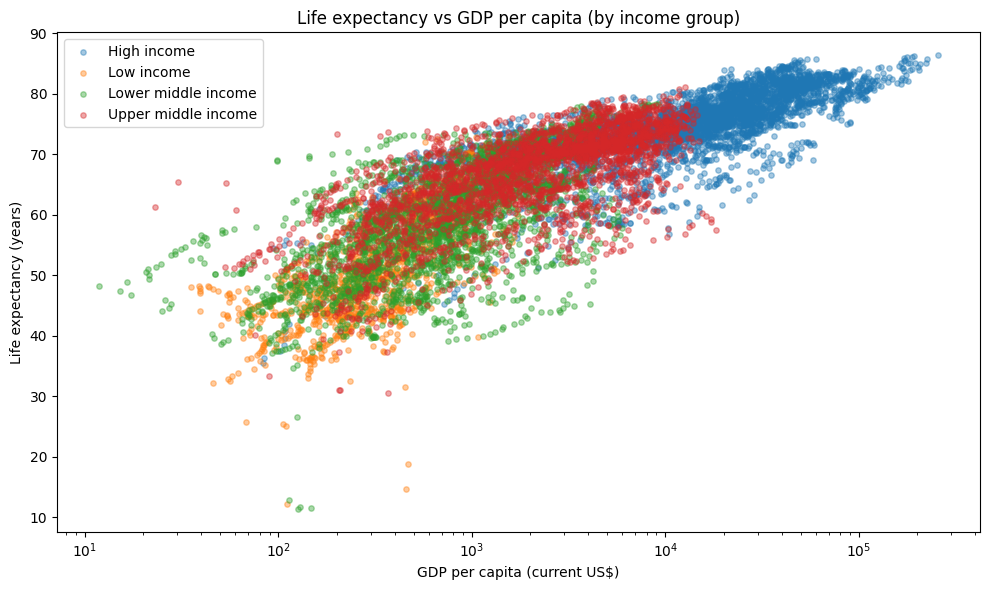

In [108]:
# life expectancy vs GDP
fig, ax = plt.subplots(figsize=(10, 6))
for ig, grp in plot_df.groupby("income_group"):
    ax.scatter(grp["gdp_per_capita_usd"], grp["life_expectancy_years"], label=ig, alpha=0.4, s=15)
ax.set_xlabel("GDP per capita (current US$)")
ax.set_ylabel("Life expectancy (years)")
ax.set_title("Life expectancy vs GDP per capita (by income group)")
ax.legend()
ax.set_xscale("log")
plt.tight_layout()
plt.show()

In [ ]:
# this shows somewhat clear relation between gdp and life expectancy

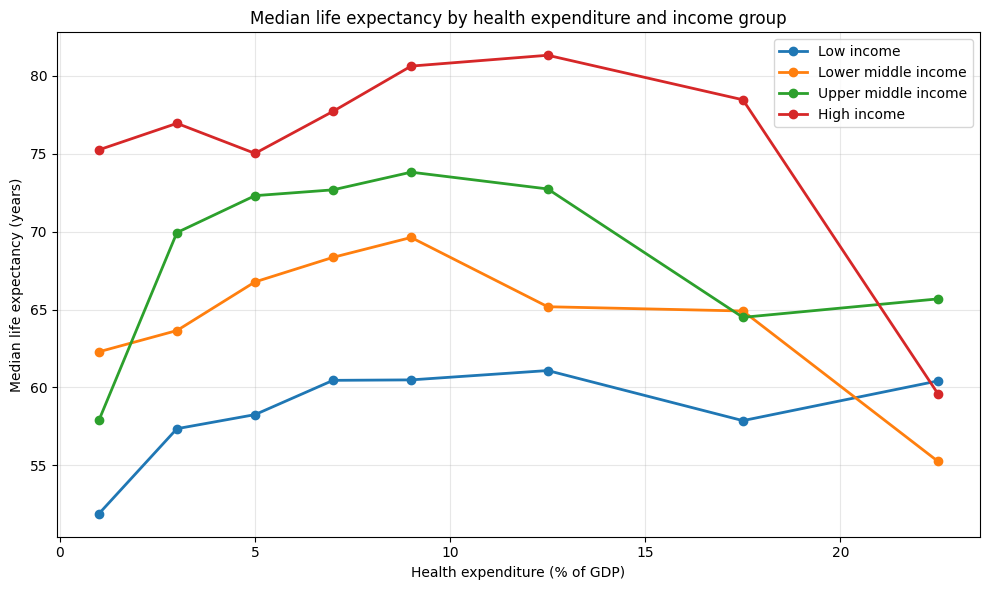

In [118]:
# median life expectancy per income group vs health expenditure
plot_health = merged_df.dropna(subset=["life_expectancy_years", "perc_health_expenditure_of_gdp", "income_group"])
plot_health = plot_health[~plot_health["income_group"].eq("")]
bins = [0, 2, 4, 6, 8, 10, 15, 20, 25]
plot_health["health_bin"] = pd.cut(plot_health["perc_health_expenditure_of_gdp"], bins=bins)
avg = plot_health.groupby(["income_group", "health_bin"], observed=True)["life_expectancy_years"].median().reset_index()
avg["bin_mid"] = avg["health_bin"].apply(lambda b: (b.left + b.right) / 2)

fig, ax = plt.subplots(figsize=(10, 6))
order = ["Low income", "Lower middle income", "Upper middle income", "High income"]
for ig in order:
    grp = avg[avg["income_group"] == ig].sort_values("bin_mid")
    if not grp.empty:
        ax.plot(grp["bin_mid"], grp["life_expectancy_years"], marker="o", lw=2, label=ig)
ax.set_xlabel("Health expenditure (% of GDP)")
ax.set_ylabel("Median life expectancy (years)")
ax.set_title("Median life expectancy by health expenditure and income group")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# countries spending more than 12.5% of GDP on health are having worse life expectancy

### Impact of Conflict on Life Expectancy
Picking a few countries with known conflict periods to see if the onset of conflict visibly disrupts life expectancy trends.

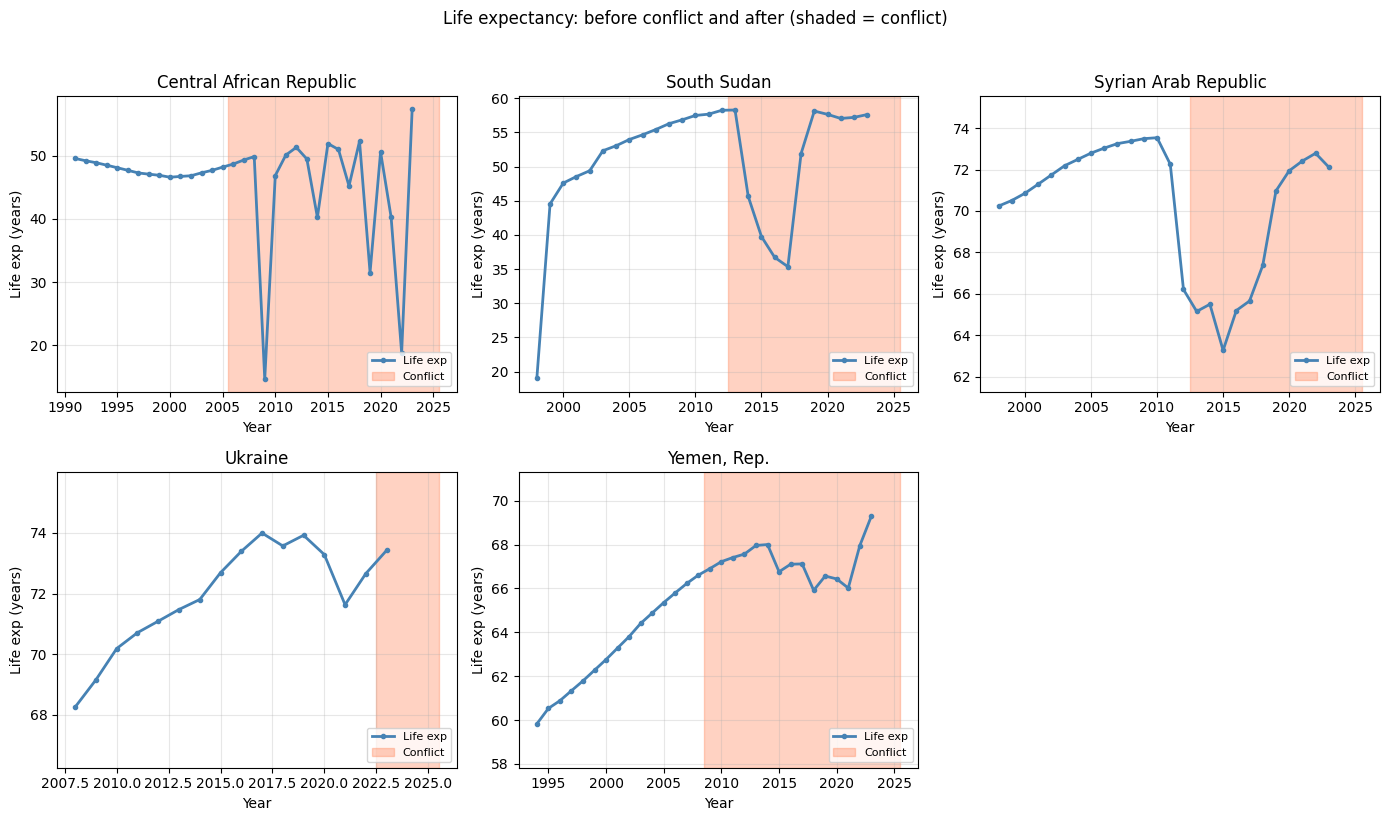

In [117]:
# before conflict and after conflict
fc = [c for c in ["SYR", "YEM", "UKR", "CAF", "SSD"] if c in merged_df["country_code"].values]
d = merged_df[merged_df["country_code"].isin(fc)].dropna(subset=["life_expectancy_years"]).sort_values(["country_code", "year"])
cr = merged_df[merged_df["is_conflict"]].groupby("country_code")["year"].agg(["min", "max"])

fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()
for i, (code, grp) in enumerate(d.groupby("country_code")):
    grp = grp[grp["year"] >= (cr.loc[code, "min"] if code in cr.index else grp["year"].min()) - 15]
    ax = axs[i]
    ax.plot(grp["year"], grp["life_expectancy_years"], color="steelblue", lw=2, marker="o", ms=3, label="Life exp")
    if code in cr.index:
        ax.axvspan(cr.loc[code, "min"] - 0.5, cr.loc[code, "max"] + 0.5, alpha=0.35, color="coral", label="Conflict")
    ax.set(title=grp["country_name"].iloc[0], xlabel="Year", ylabel="Life exp (years)")
    ax.set_ylim(grp["life_expectancy_years"].min() - 2, grp["life_expectancy_years"].max() + 2)
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, alpha=0.3)
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)
plt.suptitle("Life expectancy: before conflict and after (shaded = conflict)", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# does show that conflict is causing life expectancy to go haywire/down but not always happening like in ukraine and yemen

### Life Expectancy by Income Group & Region
Aggregating trends by World Bank income classifications and geographic regions to see if macro-level groupings explain the variance.

In [99]:
# avg life expectancy by income group
by_income = (
    merged_df[merged_df["income_group"].notna() & (merged_df["income_group"] != "")]
    .groupby("income_group")["life_expectancy_years"]
    .agg(["mean", "count"])
    .round(2)
)
by_income.sort_values("mean", ascending=False)

,mean,count
income_group,,
High income,73.28,5500
Upper middle income,65.96,3456
Lower middle income,58.08,3170
Low income,50.59,1600


In [ ]:
# very clear relation of life expectancy and income groip

In [101]:
# avg life expectancy by region
by_region = (
    merged_df[merged_df["region"].notna() & (merged_df["region"] != "") & ~merged_df["is_aggregated_region"]]
    .groupby("region")["life_expectancy_years"]
    .agg(["mean", "count"])
    .round(2)
    .sort_values("mean", ascending=False)
)
by_region

,mean,count
region,,
North America,75.68,192
Europe & Central Asia,72.67,3712
Latin America & Caribbean,68.43,2688
East Asia & Pacific,66.10,2368
Middle East & North Africa,65.40,1438
South Asia,59.99,384
Sub-Saharan Africa,52.68,3072


In [ ]:
# also kinda clear relation here with region